In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo
import matplotlib
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import momlevel as ml
import numpy as np
import seaborn as sns
import xarray as xr

In [32]:
ds_ice_id = xr.open_dataset("/work/Katherine.Turner/BGOSE/data_i000_SO65/iceshelves_bgose6_extended.nc")
ds_T = xr.open_dataset("/work/Katherine.Turner/BGOSE/data_i000_SO65/Theta_bgoseI000s65_2013to_monthly.nc")
ds_S = xr.open_dataset("/work/Katherine.Turner/BGOSE/data_i000_SO65/Salt_bgoseI000s65_2013to_monthly.nc")

In [4]:
idx_shelf = (ds_T.Depth <= 1000) & (ds_T.Depth > 0)

In [5]:
idx_AP = ds_ice_id.shelf_mask.isin(np.arange(1, 12)) & idx_shelf
idx_WA = ds_ice_id.shelf_mask.isin(np.arange(13, 27)) & idx_shelf
idx_RS = ds_ice_id.shelf_mask.isin(np.arange(27, 29)) & idx_shelf
idx_EA = ds_ice_id.shelf_mask.isin(np.arange(29, 66)) & idx_shelf
idx_RF = ds_ice_id.shelf_mask.isin([12, 66]) & idx_shelf
idx_other = (ds_ice_id.shelf_mask == 0) & idx_shelf

In [33]:
Theta_AP = ds_T.THETA.where(idx_AP)
Theta_WA = ds_T.THETA.where(idx_WA)
Theta_EA = ds_T.THETA.where(idx_EA)
Theta_RF = ds_T.THETA.where(idx_RF)

Salt_AP = ds_S.SALT.where(idx_AP)
Salt_WA = ds_S.SALT.where(idx_WA)
Salt_EA = ds_S.SALT.where(idx_EA)
Salt_RF = ds_S.SALT.where(idx_RF)

In [24]:
T_WA_detrended = ml.trend.linear_detrend(Theta_WA[24:,:,:,:])
WA_model, resid = ml.trend.seasonal_model(T_WA_detrended, return_model=True)
WA_model2 = WA_model.groupby(WA_model.time.dt.month).mean()

T_EA_detrended = ml.trend.linear_detrend(Theta_EA[24:,:,:,:])
EA_model, resid = ml.trend.seasonal_model(T_EA_detrended, return_model=True)
EA_model2 = EA_model.groupby(EA_model.time.dt.month).mean()

T_RF_detrended = ml.trend.linear_detrend(Theta_RF[24:,:,:,:])
RF_model, resid = ml.trend.seasonal_model(T_RF_detrended, return_model=True)
RF_model2 = RF_model.groupby(RF_model.time.dt.month).mean()

/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecat

In [34]:
S_WA_detrended = ml.trend.linear_detrend(Salt_WA[24:,:,:,:])
WA_model, resid = ml.trend.seasonal_model(S_WA_detrended, return_model=True)
WA_model2 = WA_model.groupby(WA_model.time.dt.month).mean()

S_EA_detrended = ml.trend.linear_detrend(Salt_EA[24:,:,:,:])
EA_model, resid = ml.trend.seasonal_model(S_EA_detrended, return_model=True)
EA_model2 = EA_model.groupby(EA_model.time.dt.month).mean()

S_RF_detrended = ml.trend.linear_detrend(Salt_RF[24:,:,:,:])
RF_model, resid = ml.trend.seasonal_model(S_RF_detrended, return_model=True)
RF_model2 = RF_model.groupby(RF_model.time.dt.month).mean()

/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  values_as_series = pd.Series(values.ravel(), copy=False)
/nbhome/Katherine.Turner/miniconda3/envs/py310/lib/python3.10/site-packages/xarray/core/accessor_dt.py:72: FutureWarning: Index.ravel returning ndarray is deprecat

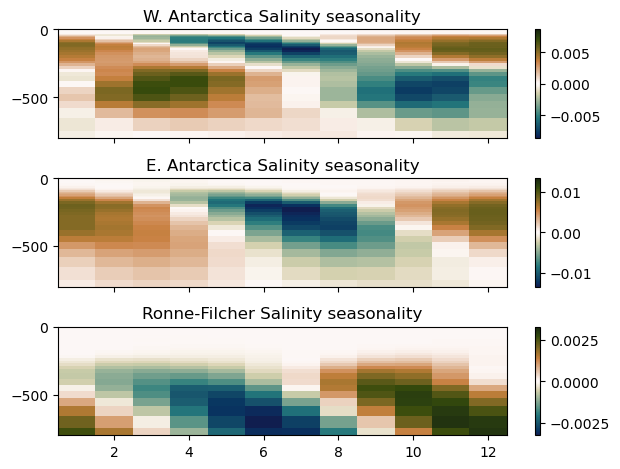

In [37]:
regions = ['W. Antarctica', 'E. Antarctica', 'Ronne-Filcher']

figs, axs = plt.subplots(nrows=3, ncols=1, sharex=True)

WA_model2.weighted(ds_T.rA).mean(dim=["YC", "XC"]).plot(ax=axs[0], cmap=cmo.cm.tarn_r)
EA_model2.weighted(ds_T.rA).mean(dim=["YC", "XC"]).plot(ax=axs[1], cmap=cmo.cm.tarn_r)
RF_model2.weighted(ds_T.rA).mean(dim=["YC", "XC"]).plot(ax=axs[2], cmap=cmo.cm.tarn_r)

for i in range(3):
    axs[i].set_ylim([-800, 0])
    axs[i].set_title(regions[i] + ' Salinity seasonality')
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    
plt.tight_layout()

In [27]:
T_WA_detrended

<xarray.DataArray 'THETA' (time: 85, Z: 52, YC: 285, XC: 2160)>
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates: (12/14)
    iter     (time) int64 ...
  * time     (time) datetime64[ns] 2015-02-01 2015-03-01 ... 2022-02-01
  * XC       (XC) float32 0.08333 0.25 0.4167 0.5833 ... 359.4 359.6 359.8 359.9
  * YC       (YC) float32 -82.97 -82.91 -82.84 -82.78 ... -65.19 -65.12 -65.05
  * Z        (Z) float32 -2.1 -6.7 -12.15 -18.55 ... -5e+03 -5.4e+03 -5.8e+03
    rA       (YC, XC) float32 1.576e+07 1.576e+07 ... 6.11e+07 6.11e+07
    ...       ...
    hFacC    (Z, YC, XC) float32 ...
    maskC    (Z, YC, XC) bool ...
    rSurfC   (YC, XC) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    rhoRef   (Z) float32 ...
    rLowC    (YC, XC) float32 0.0 0.0 0.0 ... -4.246e+03 -4.12e+03 -3.944e+03
    maskInC  (YC, XC) bool False False False False False ... True True True True
Attributes:
    standard_name:    THETA
    long_name:        Potential Temperature
    units:            degC
    detrend_comment:  detrended using momlevel (mode=remove) with m=<xarray.D...

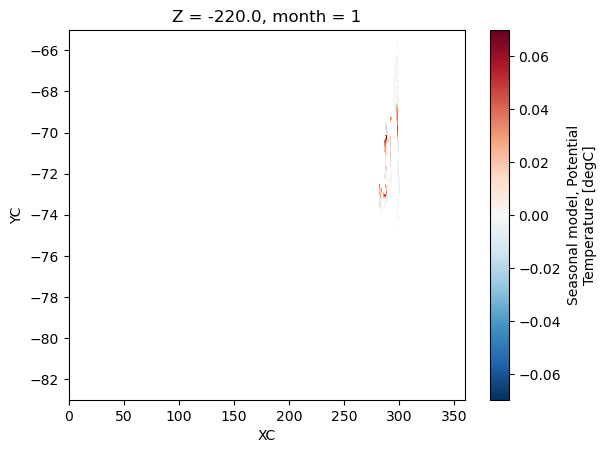

In [21]:
seasonal_model2[:,:,20,0].T.plot()